In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("fire_nrt_J1V-C2_725729.csv")

Standardize the data

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = df.select_dtypes(include=['int64', 'float64'])
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [5]:
# Decide how many components to keep
import numpy as np

explained_var = pca.explained_variance_ratio_
print(explained_var)
print(np.cumsum(explained_var))  # cumulative

[0.24428564 0.19127578 0.14610135 0.11449188 0.10419874 0.09450054
 0.06729961 0.03784647]
[0.24428564 0.43556141 0.58166276 0.69615465 0.80035338 0.89485392
 0.96215353 1.        ]


Our dataset doesn't compose neatly into 2 dimensions. 2 components keep only 43% of the data. We should keep 6-7 components, if we want to retain ~90% of the data. 

In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=['PC1', 'PC2']
)

print(loadings)

     latitude  longitude  brightness      scan     track  acq_time  \
PC1 -0.309588  -0.005220    0.560880 -0.155337 -0.190122 -0.095178   
PC2 -0.134425   0.074657    0.145539  0.653089  0.657114 -0.026027   

     bright_t31       frp  
PC1    0.622229  0.364745  
PC2   -0.019051  0.309532  


Findings: 
1. PC1: composed of brightness, bright_t31 and frp
2. PC2: composed of scan and track (satellite measurement geometry)

In [6]:
# Visualize
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

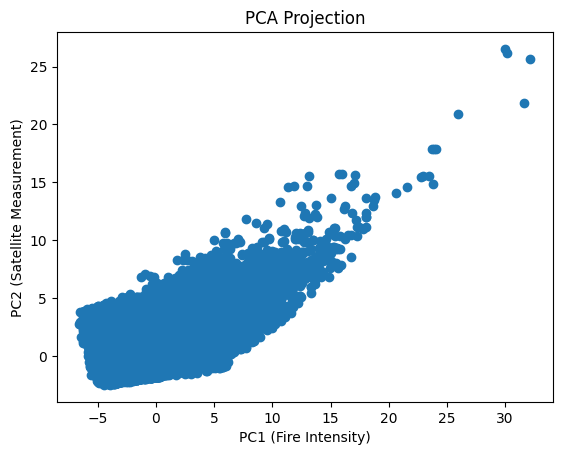

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1 (Fire Intensity)")
plt.ylabel("PC2 (Satellite Measurement)")
plt.title("PCA Projection")
plt.show()